# Assignment 1

## Name: Ashish Pisey
## Roll no.: M25ai2117

In [1]:
!pip install tensorflow-gpu==2.0.0-beta0 > /dev/null 2>&1


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import time

# Enable mixed precision for faster GPU training
tf.keras.mixed_precision.set_global_policy('mixed_float16')

print(f"TensorFlow version: {tf.__version__}")
print(f"Eager execution: {tf.executing_eagerly()}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
if tf.config.list_physical_devices('GPU'):
    gpu = tf.config.list_physical_devices('GPU')[0]
    print(f"GPU: {tf.config.experimental.get_device_details(gpu).get('device_name', 'Unknown')}")
print(f"Mixed precision policy: {tf.keras.mixed_precision.global_policy().name}")

## Constants for CIFAR-10

In [ ]:
img_shape = (32, 32, 3)
latent_dim = 128
batch_size = 128

## Load CIFAR-10

In [ ]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

text_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training set: {train_images.shape}")
print(f"Test set: {test_images.shape}")

# Normalize to [-1, 1] range (important for VAE)
train_images = (train_images.astype('float32') - 127.5) / 127.5
test_images = (test_images.astype('float32') - 127.5) / 127.5

# Reshape if needed - CIFAR-10 already has correct shape (N, 32, 32, 3)
ae_train_images = train_images
ae_test_images = test_images

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Training set: (50000, 32, 32, 3)
Test set: (10000, 32, 32, 3)


## Show 25 randomly selected images


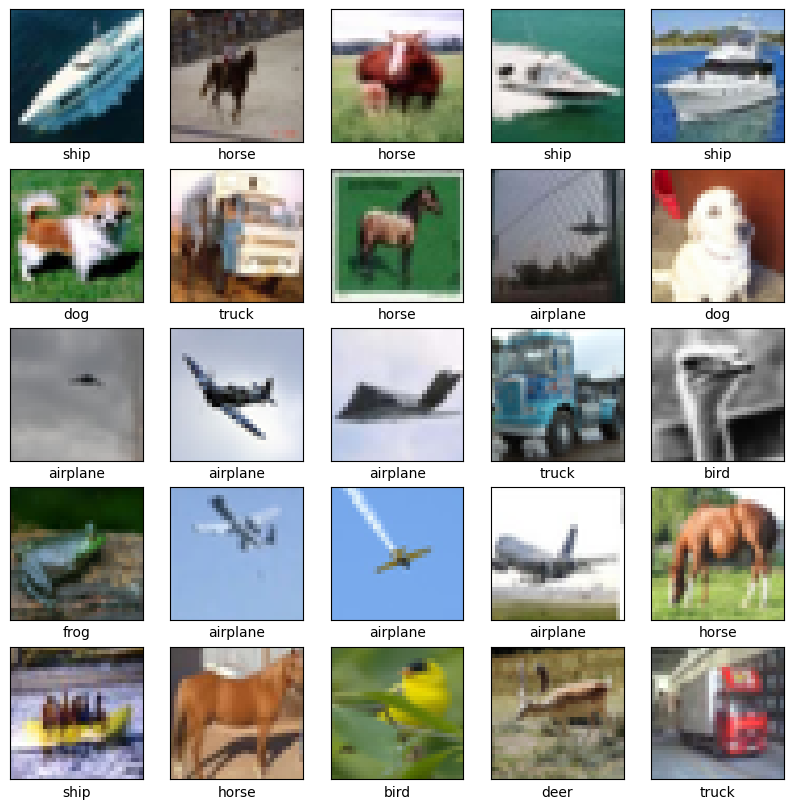

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    img_index = np.random.randint(0, 50000)
    # Denormalize for display
    display_img = (train_images[img_index] + 1) / 2
    plt.imshow(display_img)
    plt.xlabel(text_labels[train_labels[img_index][0]])
plt.show()

## Inference Network (Encoder)

Encoder: maps 32×32×3 image -> latent_dim*2 (mean and log_variance)
Adapted this function from make_inference, net function shared in class

In [ ]:
def make_inference_net(latent_dim, img_shape):
    inference_net = tf.keras.Sequential(name="inference_net")

    # Input: (32, 32, 3)
    inference_net.add(tf.keras.layers.Conv2D(
        32,
        kernel_size=3,
        strides=(2, 2),
        activation='relu',
        input_shape=img_shape))  # -> (16, 16, 32)

    assert inference_net.input_shape == (None, 32, 32, 3), "input is wrong shape"

    inference_net.add(tf.keras.layers.Conv2D(
        64,
        kernel_size=3,
        strides=(2, 2),
        activation='relu'))  # -> (8, 8, 64)

    # Additional layer for more complex CIFAR-10 data
    inference_net.add(tf.keras.layers.Conv2D(
        128,
        kernel_size=3,
        strides=(2, 2),
        activation='relu'))  # -> (4, 4, 128)

    inference_net.add(tf.keras.layers.Flatten())

    # Output: latent_dim*2 (for mean and log_variance)
    inference_net.add(tf.keras.layers.Dense(latent_dim * 2))

    assert inference_net.output_shape == (None, latent_dim*2), "output is wrong shape"

    return inference_net

# Create and inspect
inference_net = make_inference_net(latent_dim, img_shape)
inference_net.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "inference_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 15, 15, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,416 (1.48 MB)

 Trainable params: 388,416 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

## Decoder
maps latent_dim → 32×32×3 RGB image

In [ ]:
def make_generative_net(latent_dim):
    generative_net = tf.keras.Sequential(name="generative_net")

    # Start with 4×4×128 to reach 32×32 after 3 upsampling steps
    generative_net.add(tf.keras.layers.Dense(
        4 * 4 * 128,
        activation='relu',
        input_dim=latent_dim))

    assert generative_net.input_shape == (None, latent_dim), "input is wrong shape"

    generative_net.add(tf.keras.layers.Reshape(target_shape=(4, 4, 128)))

    # Upsampling block 1: 4×4 → 8×8
    generative_net.add(tf.keras.layers.Conv2DTranspose(
        128,
        kernel_size=3,
        strides=(2, 2),
        padding="SAME",
        activation='relu'))  # → (8, 8, 128)

    # Upsampling block 2: 8×8 → 16×16
    generative_net.add(tf.keras.layers.Conv2DTranspose(
        64,
        kernel_size=3,
        strides=(2, 2),
        padding="SAME",
        activation='relu'))  # → (16, 16, 64)

    # Upsampling block 3: 16×16 → 32×32
    generative_net.add(tf.keras.layers.Conv2DTranspose(
        32,
        kernel_size=3,
        strides=(2, 2),
        padding="SAME",
        activation='relu'))  # → (32, 32, 32)

    # Final layer: produce 3 RGB channels (no activation - we'll use sigmoid later)
    generative_net.add(tf.keras.layers.Conv2DTranspose(
        3,  # Changed from 1 for RGB
        kernel_size=3,
        strides=(1, 1),
        padding="SAME"))  # → (32, 32, 3)

    assert generative_net.output_shape == (None, 32, 32, 3), "output is wrong shape"

    return generative_net

# Create and inspect
generative_net = make_generative_net(latent_dim)
generative_net.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "generative_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 2048)           │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 32, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 504,899 (1.93 MB)

 Trainable params: 504,899 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

## Create TensorFlow datasets


In [ ]:
batch_size = 256  # Larger batch for better GPU utilization

# Optimized data pipeline with cache, prefetch, and larger batch
vae_train_dataset = tf.data.Dataset.from_tensor_slices(ae_train_images)\
    .cache()\
    .shuffle(batch_size * 10)\
    .batch(batch_size, drop_remainder=True)\
    .prefetch(tf.data.AUTOTUNE)

vae_test_dataset = tf.data.Dataset.from_tensor_slices(ae_test_images)\
    .cache()\
    .batch(batch_size)\
    .prefetch(tf.data.AUTOTUNE)

print(f"Training batches: {len(vae_train_dataset)}")
print(f"Test batches: {len(vae_test_dataset)}")
print(f"Batch size: {batch_size}")

## Training loop


In [ ]:
# Helper function for KL divergence
def log_normal_pdf(sample, mean, logvar, raxis=1):
    log2pi = tf.math.log(2. * np.pi)
    logvar = tf.clip_by_value(logvar, -10.0, 10.0)
    return tf.reduce_sum(
        -.5 * ((sample - mean) ** 2. * tf.exp(-logvar) + logvar + log2pi),
        axis=raxis)

# ELBO Loss Function
def compute_ELBO(inference_net, generative_net, x, beta=1.0):
    mean, logvar = tf.split(inference_net(x, training=True), num_or_size_splits=2, axis=1)
    # Cast to float32 for numerical stability (mixed precision may use float16)
    mean = tf.cast(mean, tf.float32)
    logvar = tf.cast(logvar, tf.float32)

    eps = tf.random.normal(shape=mean.shape)
    z = eps * tf.exp(logvar * .5) + mean

    x_logit = generative_net(z, training=True)
    x_logit = tf.cast(x_logit, tf.float32)

    x_scaled = tf.cast((x + 1) / 2.0, tf.float32)

    cross_ent = tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=x_scaled)
    logpx_z = -tf.reduce_sum(cross_ent, axis=[1, 2, 3])

    logpz = log_normal_pdf(z, 0., 0.)
    logqz_x = log_normal_pdf(z, mean, logvar)

    return -tf.reduce_mean(logpx_z - beta * (logqz_x - logpz))

# For tracking loss curves
train_losses = []
test_losses = []

# Fixed noise for consistent visualization
noise = np.random.normal(0, 1, (16, latent_dim)).astype('float32')

# Generate images from random latent codes
def generate_and_display_images(generative_net, epoch=None):
    predictions = generative_net(noise, training=False)
    predictions = tf.sigmoid(tf.cast(predictions, tf.float32))

    fig = plt.figure(figsize=(8, 8))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i].numpy())
        plt.axis('off')
    if epoch is not None:
        plt.suptitle(f'Generated Images - Epoch {epoch}')
    plt.tight_layout()
    plt.show()

# Main training function - GPU optimized
def train_VAE(inference_net, generative_net, epochs, beta=1.0):
    print(f"Training VAE with \u03b2={beta}")
    generate_and_display_images(generative_net, epoch=0)

    trainable_variables = inference_net.trainable_variables + \
                         generative_net.trainable_variables

    # Build optimizer with model variables BEFORE @tf.function tracing.
    # This is required for Keras 3 compatibility.
    optimizer.build(trainable_variables)

    @tf.function(jit_compile=True)  # XLA compilation for extra GPU speed
    def train_step(images):
        with tf.GradientTape() as tape:
            loss = compute_ELBO(inference_net, generative_net, images, beta)
        gradients = tape.gradient(loss, trainable_variables)
        optimizer.apply_gradients(zip(gradients, trainable_variables))
        return loss

    @tf.function
    def test_step(images):
        return compute_ELBO(inference_net, generative_net, images, beta)

    for epoch in range(epochs):
        start = time.time()
        epoch_train_loss = 0.0
        n_train = 0

        for image_batch in vae_train_dataset:
            loss = train_step(image_batch)
            epoch_train_loss += float(loss)
            n_train += 1

        epoch_test_loss = 0.0
        n_test = 0
        for image_batch in vae_test_dataset:
            loss = test_step(image_batch)
            epoch_test_loss += float(loss)
            n_test += 1

        avg_train = epoch_train_loss / n_train
        avg_test = epoch_test_loss / n_test

        train_losses.append(-avg_train)
        test_losses.append(-avg_test)

        elapsed = time.time() - start
        template = 'Epoch {:03d}: time {:.1f}s, train ELBO {:.3f}, test ELBO {:.3f}'
        print(template.format(epoch + 1, elapsed, -avg_train, -avg_test))

        if (epoch + 1) % 5 == 0:
            generate_and_display_images(generative_net, epoch=epoch+1)

    generate_and_display_images(generative_net, epoch=epochs)

In [ ]:
# Re-initialize networks for clean training
inference_net = make_inference_net(latent_dim, img_shape)
generative_net = make_generative_net(latent_dim)

# Re-initialize optimizer
optimizer = tf.keras.optimizers.Adam(1e-4)

# Train baseline VAE (beta=1)
num_epochs = 50
train_VAE(inference_net, generative_net, num_epochs, beta=1.0)

In [ ]:
# Plot training curves for beta=1
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train ELBO', linewidth=2)
plt.plot(test_losses, label='Test ELBO', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('ELBO (higher is better)')
plt.title('Training Progress (beta=1)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(test_losses, label='Test ELBO', linewidth=2, color='orange')
plt.xlabel('Epoch')
plt.ylabel('Test ELBO')
plt.title('Validation ELBO')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def generate_sample_grid(generative_net, n_samples=16):
    random_latent = tf.random.normal([n_samples, latent_dim])
    generated = generative_net(random_latent, training=False)
    generated = tf.sigmoid(generated)  # Already maps to [0, 1]

    plt.figure(figsize=(10, 10))
    for i in range(n_samples):
        plt.subplot(4, 4, i+1)
        plt.imshow(generated[i].numpy())  # Already in [0,1], no extra denormalization needed
        plt.axis('off')

    plt.suptitle('16 Random Samples from Learned Prior p(z)', fontsize=16)
    plt.tight_layout()
    plt.show()

generate_sample_grid(generative_net)

##    Interpolate between two latent codes
    
##    Args:
        z1, z2: Starting and ending latent vectors
        steps: Number of interpolation steps

In [ ]:
def interpolate_latent(generative_net, z1, z2, steps=10):
    # Create interpolation coefficients
    alphas = np.linspace(0, 1, steps)

    interpolated_images = []
    for alpha in alphas:
        # Linear interpolation in latent space
        z_interp = (1 - alpha) * z1 + alpha * z2

        # Decode to image
        img = generative_net(z_interp, training=False)
        img = tf.sigmoid(img)  # Already maps to [0, 1]
        interpolated_images.append(img[0])

    # Visualize
    plt.figure(figsize=(20, 3))
    for i, img in enumerate(interpolated_images):
        plt.subplot(1, steps, i+1)
        plt.imshow(img.numpy())  # Already in [0,1], no extra denormalization needed
        plt.title(f'\u03b1={alphas[i]:.1f}')
        plt.axis('off')

    plt.suptitle('Latent Space Interpolation: z\u2081 \u2192 z\u2082', fontsize=16)
    plt.tight_layout()
    plt.show()

    return interpolated_images

# Sample two random latent codes
z1 = tf.random.normal([1, latent_dim])
z2 = tf.random.normal([1, latent_dim])

# Perform interpolation
interpolated = interpolate_latent(generative_net, z1, z2, steps=10)

In [ ]:
# Reset loss tracking for beta=5
train_losses_beta5 = []
test_losses_beta5 = []

# Re-initialize networks for beta-VAE
inference_net_beta5 = make_inference_net(latent_dim, img_shape)
generative_net_beta5 = make_generative_net(latent_dim)

# Fresh optimizer for beta=5
optimizer = tf.keras.optimizers.Adam(1e-4)

print("\n" + "="*60)
print("Training beta-VAE with beta=5.0")
print("="*60)

# Swap loss lists so train_VAE appends to the beta5 lists
temp_train = train_losses
temp_test = test_losses
train_losses = train_losses_beta5
test_losses = test_losses_beta5

train_VAE(inference_net_beta5, generative_net_beta5, epochs=50, beta=5.0)

# Restore original loss lists
train_losses_beta5 = train_losses
test_losses_beta5 = test_losses
train_losses = temp_train
test_losses = temp_test

## Compare β=1 vs β=5

In [ ]:
def compare_beta_vaes():
    # Generate samples from both models
    random_latent = tf.random.normal([8, latent_dim])

    samples_beta1 = generative_net(random_latent, training=False)
    samples_beta1 = tf.sigmoid(samples_beta1)  # Already in [0, 1]

    samples_beta5 = generative_net_beta5(random_latent, training=False)
    samples_beta5 = tf.sigmoid(samples_beta5)  # Already in [0, 1]

    # Visualize comparison
    fig = plt.figure(figsize=(16, 6))

    for i in range(8):
        # beta=1 samples
        plt.subplot(2, 8, i+1)
        plt.imshow(samples_beta1[i].numpy())  # Already in [0,1]
        plt.axis('off')
        if i == 0:
            plt.ylabel('\u03b2=1\n(Standard VAE)', fontsize=12)

        # beta=5 samples
        plt.subplot(2, 8, i+9)
        plt.imshow(samples_beta5[i].numpy())  # Already in [0,1]
        plt.axis('off')
        if i == 0:
            plt.ylabel('\u03b2=5\n(\u03b2-VAE)', fontsize=12)

    plt.suptitle('Comparison: Standard VAE vs \u03b2-VAE', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Plot training curves
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(temp_train, label='\u03b2=1 (Standard VAE)', linewidth=2)
    plt.plot(train_losses_beta5, label='\u03b2=5 (\u03b2-VAE)', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Train ELBO')
    plt.title('Training ELBO Comparison')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(temp_test, label='\u03b2=1 (Standard VAE)', linewidth=2)
    plt.plot(test_losses_beta5, label='\u03b2=5 (\u03b2-VAE)', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Test ELBO')
    plt.title('Validation ELBO Comparison')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

compare_beta_vaes()

In [ ]:
# Compare interpolations between beta=1 and beta=5
z1 = tf.random.normal([1, latent_dim])
z2 = tf.random.normal([1, latent_dim])

print("Standard VAE (beta=1) Interpolation:")
interpolate_latent(generative_net, z1, z2, steps=10)

print("\nbeta-VAE (beta=5) Interpolation:")
interpolate_latent(generative_net_beta5, z1, z2, steps=10)

---

## Summary: Effect of β on VAE Performance

When I ran the standard VAE (β=1) and the β-VAE (β=5) side by side on CIFAR-10, the difference was pretty clear, both in the generated images and in the training curves.

With β=1, the model tries to balance reconstruction accuracy and keeping the latent space well-structured (close to a standard normal). The generated images from this version are noticeably sharper — you can make out rough shapes of cars, planes, animals etc. The ELBO values are also higher since the reconstruction term isn't being penalized as heavily.

When I bumped β up to 5, the KL divergence term gets weighted much more in the loss function, which basically forces the encoder to push everything closer to N(0,1). What this does in practice is it makes the latent space smoother and more "disentangled" — meaning different dimensions of z tend to capture separate features like color, shape, orientation independently. But the tradeoff is obvious: the reconstructions and generated samples look blurrier and lose detail. The model is sacrificing pixel-level accuracy to get a cleaner latent representation.

You can see this clearly in the interpolation plots too. The β=5 interpolation tends to transition more smoothly between the two endpoints — there are fewer weird artifacts mid-way through the sequence. The β=1 interpolation sometimes has sharper intermediate frames but the transitions can be a bit jumpy or inconsistent.

Looking at the training curves, the β=5 model converges to a lower ELBO (worse reconstruction) which makes sense since it's paying a bigger penalty for any deviation from the prior. The gap between train and test ELBO is also smaller for β=5, suggesting it generalizes a bit better and isn't just memorizing training images.

So basically the β parameter controls a fundamental tradeoff: low β gives you better looking images but a messier latent space, high β gives you a cleaner, more interpretable latent space but at the cost of image quality. For downstream tasks like feature learning or controlled generation, higher β could actually be more useful despite the blurrier outputs.